# 2D Incompressible Navier–Stokes — Taylor–Green Vortex

**Governing equations** on $\Omega = [0, 2\pi]^2 \times [0, 1]$:
$$u_t + u\,u_x + v\,u_y = -p_x + \nu(u_{xx} + u_{yy})$$
$$v_t + u\,v_x + v\,v_y = -p_y + \nu(v_{xx} + v_{yy})$$
$$u_x + v_y = 0$$

**Analytic Taylor–Green vortex** (periodic on $[0, 2\pi]^2$):
$$u(x,y,t) = -\cos x\,\sin y\,e^{-2\nu t}, \quad v(x,y,t) = \sin x\,\cos y\,e^{-2\nu t}, \quad p(x,y,t) = -\tfrac14(\cos 2x + \cos 2y)\,e^{-4\nu t}$$

Network outputs $(u, v, p)$; the LC-PINN λ order is **[pde, bc, ic, data]**.

This notebook:
1. Trains LC-PINN (uniform sampling) for NS.
2. Trains an equal-weights fixed baseline.
3. Sweeps λ (fair: `exclude_terms=set()`), evaluates rel-L2 on (u, v) vs analytic.
4. Visualises the vortex at a few snapshots.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from pinns.model import LossConditionalPINN
from pinns.baseline import FixedWeightPINN, train_fixed_pinn
from pinns.lambda_sampler import LambdaSampler
from pinns.training import train_lc_pinn
from pinns.inference import sweep_lambda
from pinns.device import select_device, device_info
from pinns.equations import navier_stokes_2d as ns

device = select_device()
print(f"Device: {device_info(device)}")
torch.manual_seed(0); np.random.seed(0)

HIDDEN_DIMS = [64, 64, 64, 64]

Device: mps (Apple GPU)


/Users/anna/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Reference solution & training batch

In [2]:
ref = ns.compute_reference_solution(nx=64, ny=64, snap_times=[0.0, 0.25, 0.5, 1.0])
batch = ns.generate_training_data(n_pde=4000, n_bc=400, n_ic=400, n_data=200, device=device)
print({k: v.shape for k, v in batch.items()})

{'coords_pde': torch.Size([4000, 3]), 'coords_bc_left': torch.Size([200, 3]), 'coords_bc_right': torch.Size([200, 3]), 'coords_bc_bot': torch.Size([200, 3]), 'coords_bc_top': torch.Size([200, 3]), 'coords_ic': torch.Size([400, 3]), 'u_ic': torch.Size([400, 1]), 'v_ic': torch.Size([400, 1]), 'coords_data': torch.Size([200, 3]), 'uv_data': torch.Size([200, 2])}


## 2. Train LC-PINN (uniform λ sampling)

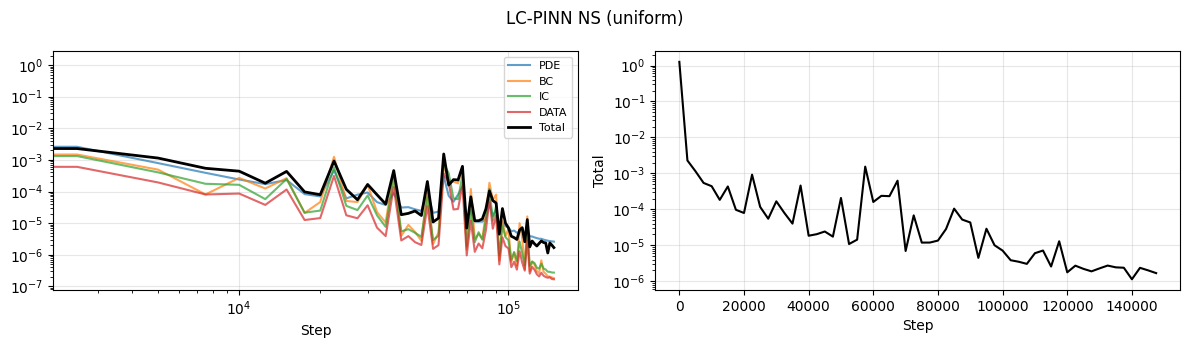

Training: 100%|██████████| 150000/150000 [2:22:18<00:00, 17.57step/s, L=1.69e-06, hw=3.00]


Training complete in 8539s (142.3 min)


In [3]:
def make_live_plot(title):
    def on_log(history):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
        fig.suptitle(title)
        steps = history['step']
        for key in history:
            if key in ('step', 'total', 'hw', 'elapsed_sec'): continue
            ax1.plot(steps, history[key], label=key.upper(), alpha=0.7)
        ax1.plot(steps, history['total'], 'k-', lw=2, label='Total')
        ax1.set_xscale('log'); ax1.set_yscale('log'); ax1.set_xlabel('Step'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
        ax2.semilogy(steps, history['total'], 'k-', lw=1.5); ax2.set_xlabel('Step'); ax2.set_ylabel('Total'); ax2.grid(alpha=0.3)
        fig.tight_layout(); plt.show(); plt.close(fig)
    return on_log

N_STEPS = 150_000  # ~60–80 min on MPS
LR = 1e-3

torch.manual_seed(42)
model_lc = LossConditionalPINN(
    dim_phys=ns.DIM_PHYS, dim_lambda=ns.DIM_LAMBDA,
    hidden_dims=HIDDEN_DIMS, dim_out=ns.DIM_OUT,
).to(device)
sampler = LambdaSampler(dim=ns.DIM_LAMBDA, device=device, mode='uniform')

history_lc = train_lc_pinn(
    model_lc, sampler, batch, device,
    loss_fn=ns.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=2_500,
    on_log=make_live_plot('LC-PINN NS (uniform)'),
)

## 3. FAIR sweep and rel-L2

In [4]:
torch.manual_seed(42)
best_ll, best_p, _ = sweep_lambda(
    model_lc, batch, sampler, device,
    loss_fn=ns.compute_losses,
    n_candidates=10_000, exclude_terms=set(),
)
print(f"Best λ (fair): {best_p.cpu().numpy().round(4)}")

lc_errs = ns.evaluate(model_lc, best_ll, ref, device)
print('\nLC-PINN per-snapshot rel-L2:')
for t_val, d in lc_errs.items():
    print(f"  t={t_val:.2f}  u={d['u']:.4f}  v={d['v']:.4f}")
print(f"\nLC-PINN mean rel-L2 (u,v): {ns.mean_rel_l2(lc_errs):.4f}")

torch.save({'model_state_dict': model_lc.state_dict(), 'best_log_lambda': best_ll},
           '../checkpoints/ns_lc_pinn_uniform.pt')

Best log(lambda):     [-0.636 -0.814 -0.867 -1.037]
Best weights (uniform): [0.5294 0.4429 0.4204 0.3547]
Best validation loss: 3.207658e-06
Best λ (fair): [0.5294 0.4429 0.4204 0.3547]

LC-PINN per-snapshot rel-L2:
  t=0.00  u=0.0008  v=0.0008
  t=0.25  u=0.0007  v=0.0008
  t=0.50  u=0.0008  v=0.0010
  t=1.00  u=0.0014  v=0.0020

LC-PINN mean rel-L2 (u,v): 0.0011


## 4. Equal-weights baseline (for comparison)

In [5]:
torch.manual_seed(42)
model_bl = FixedWeightPINN(
    dim_phys=ns.DIM_PHYS, hidden_dims=HIDDEN_DIMS, dim_out=ns.DIM_OUT,
).to(device)

history_bl = train_fixed_pinn(
    model_bl, weights=[0.25, 0.25, 0.25, 0.25],
    batch=batch, device=device,
    loss_fn=ns.compute_losses_fixed,
    n_epochs=N_STEPS, lr=LR, log_every=2_500,
    desc='NS equal-weights baseline',
)

bl_errs = ns.evaluate(model_bl, None, ref, device)
print('\nBaseline per-snapshot rel-L2:')
for t_val, d in bl_errs.items():
    print(f"  t={t_val:.2f}  u={d['u']:.4f}  v={d['v']:.4f}")
print(f"\nBaseline mean rel-L2 (u,v): {ns.mean_rel_l2(bl_errs):.4f}")

torch.save({'model_state_dict': model_bl.state_dict()},
           '../checkpoints/ns_baseline_equal.pt')

NS equal-weights baseline: 100%|██████████| 150000/150000 [33:48<00:00, 73.95step/s, L=5.23e-07]

NS equal-weights baseline done in 2028s (33.8 min)

Baseline per-snapshot rel-L2:
  t=0.00  u=0.0007  v=0.0006
  t=0.25  u=0.0006  v=0.0005
  t=0.50  u=0.0006  v=0.0006
  t=1.00  u=0.0011  v=0.0010

Baseline mean rel-L2 (u,v): 0.0007


## 5. Visualise u-component at snapshots

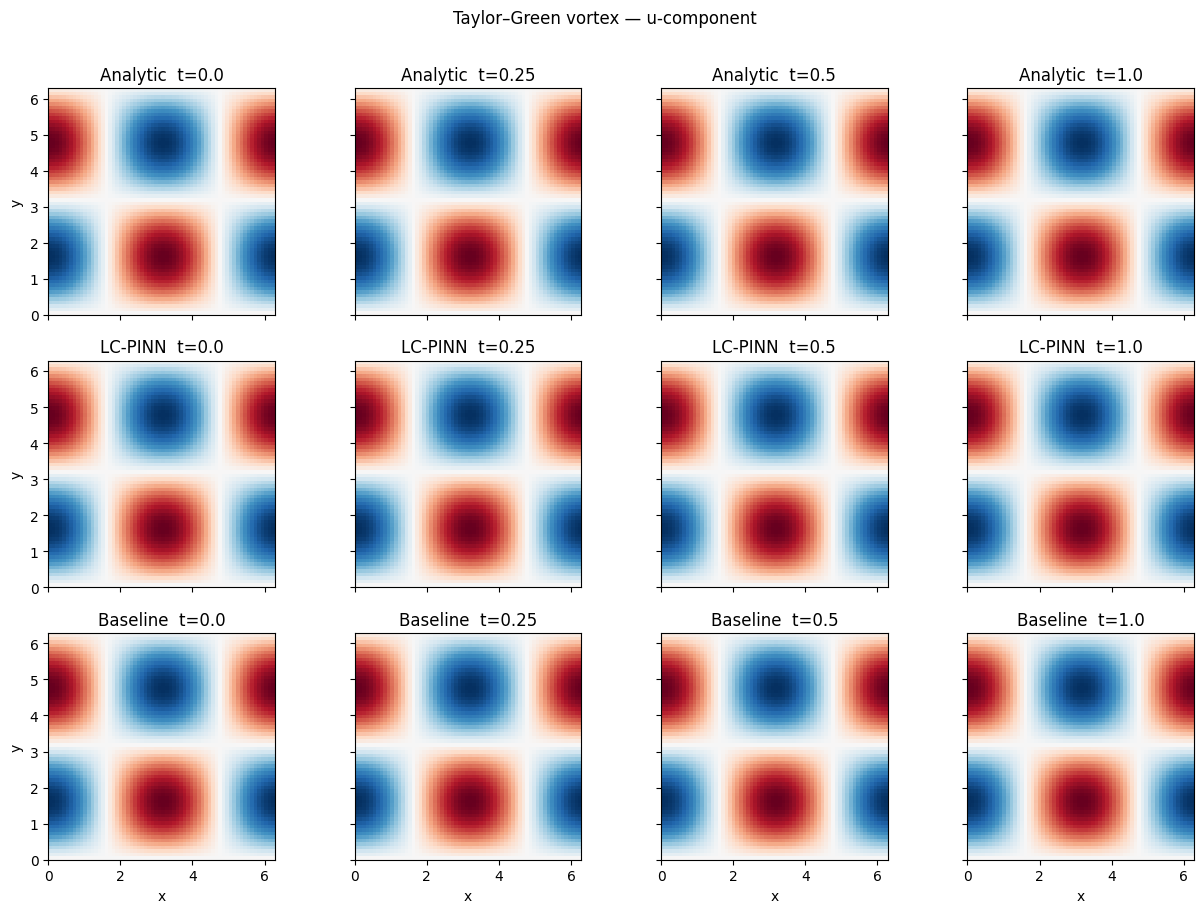

Saved: ../results/fig_ns_taylor_green_u.png


In [6]:
snap_times = sorted(ref.keys())
fig, axes = plt.subplots(3, len(snap_times), figsize=(3.2 * len(snap_times), 9), sharex=True, sharey=True)

for col, t_val in enumerate(snap_times):
    X, Y, u_ref, v_ref, _ = ref[t_val]
    u_lc, v_lc, _ = ns.predict_uvp(model_lc, best_ll, X, Y, t_val, device)
    u_bl, v_bl, _ = ns.predict_uvp(model_bl, None,    X, Y, t_val, device)

    vmin, vmax = float(u_ref.min()), float(u_ref.max())
    kw = dict(cmap='RdBu_r', vmin=vmin, vmax=vmax, origin='lower',
              extent=[ns.X_MIN, ns.X_MAX, ns.Y_MIN, ns.Y_MAX], aspect='equal')

    axes[0, col].imshow(u_ref.T, **kw); axes[0, col].set_title(f'Analytic  t={t_val}')
    axes[1, col].imshow(u_lc.T,  **kw); axes[1, col].set_title(f'LC-PINN  t={t_val}')
    axes[2, col].imshow(u_bl.T,  **kw); axes[2, col].set_title(f'Baseline  t={t_val}')

for ax in axes[:, 0]: ax.set_ylabel('y')
for ax in axes[-1]:   ax.set_xlabel('x')
fig.suptitle('Taylor–Green vortex — u-component', y=1.01)
plt.tight_layout()
plt.savefig('../results/fig_ns_taylor_green_u.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../results/fig_ns_taylor_green_u.png')

## 6. Save comparison summary

In [7]:
import json
summary = {
    'config': {
        'nu': ns.NU,
        'n_steps': N_STEPS, 'lr': LR, 'hidden_dims': HIDDEN_DIMS,
        'n_pde': 4000, 'n_bc': 400, 'n_ic': 400, 'n_data': 200,
    },
    'lc_pinn_uniform': {
        'best_lambda': best_p.cpu().numpy().round(4).tolist(),
        'per_snapshot': {str(k): v for k, v in lc_errs.items()},
        'mean_rel_l2': ns.mean_rel_l2(lc_errs),
    },
    'baseline_equal': {
        'per_snapshot': {str(k): v for k, v in bl_errs.items()},
        'mean_rel_l2': ns.mean_rel_l2(bl_errs),
    },
}
with open('../results/ns_taylor_green_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved: ../results/ns_taylor_green_results.json')
print(json.dumps(summary, indent=2))

Saved: ../results/ns_taylor_green_results.json
{
  "config": {
    "nu": 0.05,
    "n_steps": 150000,
    "lr": 0.001,
    "hidden_dims": [
      64,
      64,
      64,
      64
    ],
    "n_pde": 4000,
    "n_bc": 400,
    "n_ic": 400,
    "n_data": 200
  },
  "lc_pinn_uniform": {
    "best_lambda": [
      0.5293999910354614,
      0.44290000200271606,
      0.4203999936580658,
      0.3546999990940094
    ],
    "per_snapshot": {
      "0.0": {
        "u": 0.0008320887382416177,
        "v": 0.0008324072786685553
      },
      "0.25": {
        "u": 0.0007478397576448895,
        "v": 0.0007941429050998741
      },
      "0.5": {
        "u": 0.0008371256301609627,
        "v": 0.000991989559777001
      },
      "1.0": {
        "u": 0.0013793779850067131,
        "v": 0.002007694016716415
      }
    },
    "mean_rel_l2": 0.0010528332339145036
  },
  "baseline_equal": {
    "per_snapshot": {
      "0.0": {
        "u": 0.0007024700163349622,
        "v": 0.000634155687169464
 